# P2 — Regression Modelling
## Istanbul Airbnb Listing Price Prediction

Github reposity: 

---

## 0. Setup — Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('All imports successful.')

All imports successful.


---
## 1. Recap & Motivation

In P1 we explored the **Inside Airbnb Istanbul dataset** (snapshot: September 2024, ~15 000+ listings), which contains structural and locational attributes of short-term rental listings across Istanbul's diverse neighbourhoods. Our regression target is **`price`** — the nightly listing price in Turkish Lira (TRY). This is a continuous variable suitable for regression.

**What P1 taught us that shapes P2 modelling choices:**

1. **Log-transform the target.** Price is strongly right-skewed; modelling on `log(price)` stabilises variance and meets linear regression assumptions. We will back-transform for final error reporting.
2. **Room type and neighbourhood are the strongest predictors** — both must be encoded as features.
3. **Multicollinearity exists** between review-count variables — we keep only `reviews_per_month` and drop the others.
4. **Geographic features matter** — latitude/longitude and neighbourhood-level median price can capture spatial price clusters.
5. **`last_review` date** can be turned into `days_since_last_review` — a freshness signal not exploited in P1.

In [2]:
# Load cleaned dataset produced at the end of P1
# If the file is not present, re-run the P1 data-cleaning pipeline below
try:
    df = pd.read_csv('istanbul_airbnb_cleaned.csv')
    print(f'Loaded cleaned dataset — shape: {df.shape}')
except FileNotFoundError:
    print('Cleaned CSV not found — downloading and re-cleaning raw data...')
    RAW_URL = 'http://data.insideairbnb.com/turkey/marmara/istanbul/2024-09-20/visualisations/listings.csv'
    df_raw = pd.read_csv(RAW_URL)
    df = df_raw.copy()
    df.drop(columns=['license', 'name', 'host_name'], inplace=True, errors='ignore')
    df['has_review'] = df['last_review'].notna().astype(int)
    df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
    df = df[(df['price'].notna()) & (df['price'] > 0)]
    df.drop_duplicates(inplace=True)
    df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
    df['room_type'] = df['room_type'].astype(str).str.strip()
    df['neighbourhood'] = df['neighbourhood'].astype(str).str.strip()
    Q1, Q3 = df['price'].quantile(0.25), df['price'].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df['price'] >= Q1 - 3*IQR) & (df['price'] <= Q3 + 3*IQR)]
    Q1_mn, Q3_mn = df['minimum_nights'].quantile(0.25), df['minimum_nights'].quantile(0.75)
    df = df[df['minimum_nights'] <= Q3_mn + 3*(Q3_mn - Q1_mn)]
    df.to_csv('istanbul_airbnb_cleaned.csv', index=False)
    print(f'Re-cleaning done — shape: {df.shape}')

# Ensure dtypes
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
df['room_type'] = df['room_type'].astype(str).str.strip()
df['neighbourhood'] = df['neighbourhood'].astype(str).str.strip()
df.head(3)

Loaded cleaned dataset — shape: (24312, 16)


,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_review
0,1342043490398914341,444141348,NaN,Fatih,41.031098,28.945879,Entire home/apt,2290.0,5,4,2025-09-19,0.58,2,180,4,1
1,1342082318675744621,304448264,NaN,Beyoglu,41.038460,28.983504,Private room,1101.0,7,4,2025-09-02,0.67,7,328,4,1
2,1342210705450176162,380165223,NaN,Beyoglu,41.034284,28.981304,Entire home/apt,3430.0,2,26,2025-08-19,3.44,13,327,26,1


---
## 2. Feature Engineering

We engineer six new features beyond the raw P1 columns, covering multiple techniques.

In [3]:
df_feat = df.copy()

# ── Feature 1 ─────────────────────────────────────────────────────────────────
# Log transform of the TARGET: log_price
# Price is right-skewed. log(price) reduces skew, stabilises variance,
# and makes the distribution closer to Normal — required for linear regression.
df_feat['log_price'] = np.log1p(df_feat['price'])
print('Feature 1 — log_price: log(1 + price)')

# ── Feature 2 ─────────────────────────────────────────────────────────────────
# Aggregation: neighbourhood_median_price
# We compute the median price per neighbourhood from the FULL dataset
# (before the train/val/test split). This captures spatial price level
# without leaking per-row target info — it is an aggregated statistic.
neigh_median = df_feat.groupby('neighbourhood')['price'].median()
df_feat['neighbourhood_median_price'] = df_feat['neighbourhood'].map(neigh_median)
print('Feature 2 — neighbourhood_median_price: median price per neighbourhood')

# ── Feature 3 ─────────────────────────────────────────────────────────────────
# Datetime decomposition: days_since_last_review
# A listing with a very recent review is actively booked → high demand → higher price.
# We compute the number of days between the last review and the snapshot date.
SNAPSHOT_DATE = pd.Timestamp('2024-09-20')
df_feat['days_since_last_review'] = (SNAPSHOT_DATE - df_feat['last_review']).dt.days
df_feat['days_since_last_review'] = df_feat['days_since_last_review'].fillna(
    df_feat['days_since_last_review'].median()   # median-impute never-reviewed listings
)
print('Feature 3 — days_since_last_review: listing freshness signal')

# ── Feature 4 ─────────────────────────────────────────────────────────────────
# Interaction term: host_listings × availability_365
# Professional hosts (high listing count) who keep their properties highly
# available tend to operate premium listings. The product captures this joint effect.
df_feat['host_avail_interaction'] = (
    df_feat['calculated_host_listings_count'] * df_feat['availability_365']
)
print('Feature 4 — host_avail_interaction: host_listing_count × availability_365')

# ── Feature 5 ─────────────────────────────────────────────────────────────────
# Binning: is_professional_host
# Hosts with ≥ 5 listings are classified as professional hosts.
# P1 showed professional hosts correlate with higher-priced properties.
df_feat['is_professional_host'] = (
    df_feat['calculated_host_listings_count'] >= 5
).astype(int)
print('Feature 5 — is_professional_host: 1 if host has ≥5 listings')

# ── Feature 6 ─────────────────────────────────────────────────────────────────
# One-hot encoding: room_type
# P1 identified room_type as the single strongest predictor.
# We one-hot encode it to allow linear models to use it directly.
room_dummies = pd.get_dummies(df_feat['room_type'], prefix='room', drop_first=True)
df_feat = pd.concat([df_feat, room_dummies], axis=1)
print(f'Feature 6 — room_type dummies: {list(room_dummies.columns)}')

print(f'\nShape after feature engineering: {df_feat.shape}')

Feature 1 — log_price: log(1 + price)
Feature 2 — neighbourhood_median_price: median price per neighbourhood
Feature 3 — days_since_last_review: listing freshness signal
Feature 4 — host_avail_interaction: host_listing_count × availability_365
Feature 5 — is_professional_host: 1 if host has ≥5 listings
Feature 6 — room_type dummies: ['room_Hotel room', 'room_Private room', 'room_Shared room']

Shape after feature engineering: (24312, 24)


In [4]:
# Quick sanity check on new features
new_cols = ['log_price', 'neighbourhood_median_price', 'days_since_last_review',
            'host_avail_interaction', 'is_professional_host']
df_feat[new_cols].describe().round(2)

,log_price,neighbourhood_median_price,days_since_last_review,host_avail_interaction,is_professional_host
count,24312.00,24312.00,24312.00,24312.00,24312.00
mean,7.79,2507.99,-180.29,4483.71,0.53
std,0.69,364.39,359.07,9773.95,0.50
min,4.39,1085.00,-375.00,0.00,0.00
25%,7.38,2300.00,-345.00,365.00,0.00
50%,7.82,2538.00,-319.00,1444.00,1.00
75%,8.26,2703.00,-226.00,4015.00,1.00
max,9.35,3828.00,4483.00,144872.00,1.00


**Summary of engineered features:**

| Feature | Technique | Expected benefit |
|---|---|---|
| `log_price` | Log/power transform | Reduces right skew; meets linear regression normality assumption |
| `neighbourhood_median_price` | Aggregation | Captures spatial price level without per-row target leakage |
| `days_since_last_review` | Datetime decomposition | Listing freshness → demand proxy |
| `host_avail_interaction` | Interaction term | Joint effect of professionalism and availability on price |
| `is_professional_host` | Binning | Non-linear step effect of host professionalism |
| `room_*` dummies | Encoding | Lets linear models use the strongest categorical predictor |

---
## 3. Train / Validation / Test Split

In [5]:
# ── Define feature matrix and target ──────────────────────────────────────────
# We model log_price (back-transform to TRY for final reporting)
# Drop non-feature columns and the raw price / log_price from X

DROP_COLS = ['id', 'host_id', 'name', 'host_name', 'neighbourhood', 'room_type',
             'last_review', 'price', 'log_price', 'license',
             'number_of_reviews', 'number_of_reviews_ltm']  # remove multicollinear review cols

feature_cols = [c for c in df_feat.columns if c not in DROP_COLS and df_feat[c].dtype != 'object']
X = df_feat[feature_cols].copy()
y = df_feat['log_price'].copy()

print('Feature columns:', feature_cols)
print(f'X shape: {X.shape}  |  y shape: {y.shape}')

# Ensure no remaining NaN
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)  # catch any remaining NaNs (e.g. columns with all-NaN median)
print("Remaining NaNs in X:", X.isnull().sum().sum())
print(f'Missing values in X: {X.isnull().sum().sum()}')

Feature columns: ['neighbourhood_group', 'latitude', 'longitude', 'minimum_nights', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'has_review', 'neighbourhood_median_price', 'days_since_last_review', 'host_avail_interaction', 'is_professional_host', 'room_Hotel room', 'room_Private room', 'room_Shared room']
X shape: (24312, 15)  |  y shape: (24312,)
Remaining NaNs in X: 0
Missing values in X: 0


In [6]:
# ── 60 / 20 / 20 split ────────────────────────────────────────────────────────
# We use a three-way split (train 60 %, validation 20 %, test 20 %).
# The validation set is used for model selection and hyperparameter tuning;
# the test set is held out until final evaluation to give an unbiased estimate.

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_SEED  # 0.25 × 0.80 = 0.20
)

print(f'Train      : {X_train.shape[0]} rows  ({X_train.shape[0]/len(X)*100:.1f} %)')
print(f'Validation : {X_val.shape[0]} rows  ({X_val.shape[0]/len(X)*100:.1f} %)')
print(f'Test       : {X_test.shape[0]} rows  ({X_test.shape[0]/len(X)*100:.1f} %)')

Train      : 14586 rows  (60.0 %)
Validation : 4863 rows  (20.0 %)
Test       : 4863 rows  (20.0 %)


In [7]:
# ── Feature Scaling ───────────────────────────────────────────────────────────
# Fit scaler ONLY on training data to prevent data leakage into val/test.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('StandardScaler fitted on training set only — applied to val & test.')

StandardScaler fitted on training set only — applied to val & test.


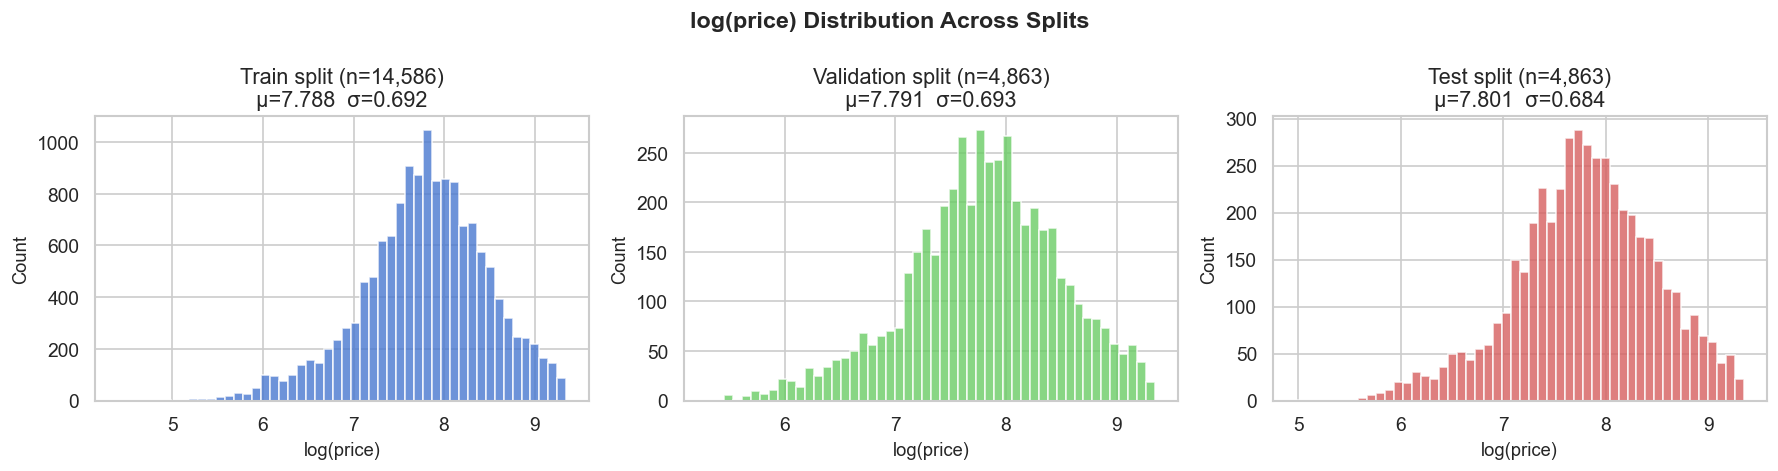

In [8]:
# ── Target distribution in each split ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
splits = [('Train', y_train), ('Validation', y_val), ('Test', y_test)]
colors = ['#4878d0', '#6acc65', '#d65f5f']

for ax, (name, y_split), color in zip(axes, splits, colors):
    ax.hist(y_split, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{name} split (n={len(y_split):,})\nμ={y_split.mean():.3f}  σ={y_split.std():.3f}')
    ax.set_xlabel('log(price)')
    ax.set_ylabel('Count')

plt.suptitle('log(price) Distribution Across Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Split rationale:** The 60/20/20 approach gives a decent training set while keeping separate validation and test sets. The validation set is used throughout sections 4–7 for model selection; the test set is only touched in Section 8. StandardScaler is fit on training data only — fitting on the full dataset would cause data leakage.

---
## 4. Baseline Model — Simple Linear Regression

We use `neighbourhood_median_price` as the single most predictive feature (it encodes both location and typical room type mix for each neighbourhood).

In [9]:
# Helper function: compute regression metrics
def reg_metrics(y_true, y_pred, label=''):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    if label:
        print(f'[{label}]  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}')
    return r2, rmse, mae

# Select the single feature
feat_baseline = ['neighbourhood_median_price']
idx = list(X_train.columns).index('neighbourhood_median_price')

X_train_bl = X_train_sc[:, idx].reshape(-1, 1)
X_val_bl   = X_val_sc[:, idx].reshape(-1, 1)
X_test_bl  = X_test_sc[:, idx].reshape(-1, 1)

lr_baseline = LinearRegression()
lr_baseline.fit(X_train_bl, y_train)

y_pred_train_bl = lr_baseline.predict(X_train_bl)
y_pred_val_bl   = lr_baseline.predict(X_val_bl)
y_pred_test_bl  = lr_baseline.predict(X_test_bl)

r2_tr_bl, rmse_tr_bl, mae_tr_bl = reg_metrics(y_train, y_pred_train_bl, 'Baseline TRAIN')
r2_val_bl, rmse_val_bl, mae_val_bl = reg_metrics(y_val, y_pred_val_bl,  'Baseline VAL  ')
r2_te_bl, rmse_te_bl, mae_te_bl   = reg_metrics(y_test, y_pred_test_bl, 'Baseline TEST ')

[Baseline TRAIN]  R²=0.0485  RMSE=0.6753  MAE=0.5242
[Baseline VAL  ]  R²=0.0437  RMSE=0.6777  MAE=0.5280
[Baseline TEST ]  R²=0.0490  RMSE=0.6673  MAE=0.5225


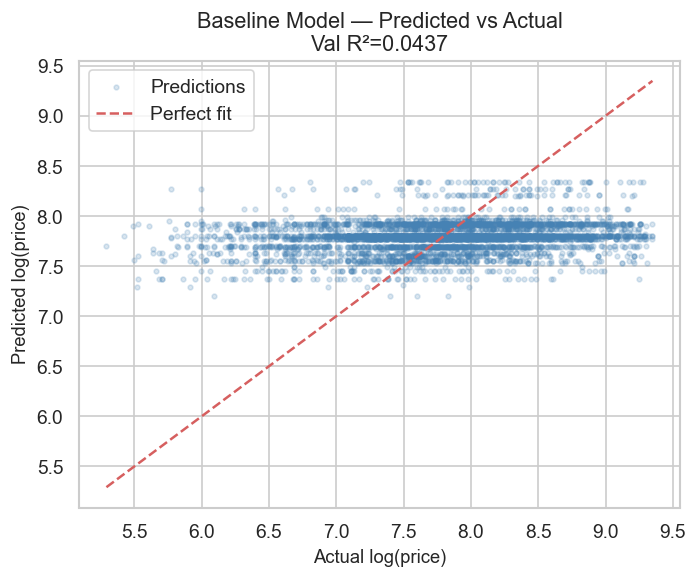

In [10]:
# Predicted vs Actual — Baseline
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_val, y_pred_val_bl, alpha=0.2, s=8, color='steelblue', label='Predictions')
lims = [min(y_val.min(), y_pred_val_bl.min()), max(y_val.max(), y_pred_val_bl.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual log(price)')
ax.set_ylabel('Predicted log(price)')
ax.set_title(f'Baseline Model — Predicted vs Actual\nVal R²={r2_val_bl:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The baseline captures some variance (neighbourhood median price is informative), but a single feature cannot account for room type, host professionalism, or listing freshness. The spread around the diagonal confirms substantial unexplained variance — this is our performance floor.

---
## 5. Multiple Linear Regression

In [11]:
lr_multi = LinearRegression()
lr_multi.fit(X_train_sc, y_train)

y_pred_train_ml = lr_multi.predict(X_train_sc)
y_pred_val_ml   = lr_multi.predict(X_val_sc)
y_pred_test_ml  = lr_multi.predict(X_test_sc)

r2_tr_ml, rmse_tr_ml, mae_tr_ml = reg_metrics(y_train, y_pred_train_ml, 'MultiLR TRAIN')
r2_val_ml, rmse_val_ml, mae_val_ml = reg_metrics(y_val, y_pred_val_ml,  'MultiLR VAL  ')
r2_te_ml, rmse_te_ml, mae_te_ml   = reg_metrics(y_test, y_pred_test_ml, 'MultiLR TEST ')

[MultiLR TRAIN]  R²=0.2511  RMSE=0.5991  MAE=0.4749
[MultiLR VAL  ]  R²=0.2374  RMSE=0.6052  MAE=0.4773
[MultiLR TEST ]  R²=0.2264  RMSE=0.6019  MAE=0.4774


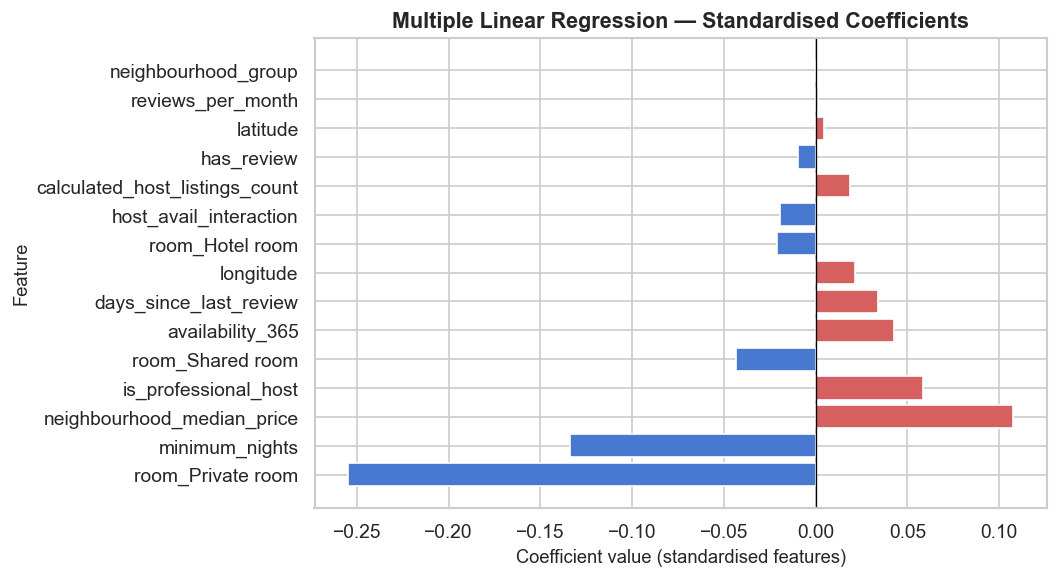

                       Feature  Coefficient
             room_Private room    -0.255000
                minimum_nights    -0.134159
    neighbourhood_median_price     0.107741
          is_professional_host     0.058419
              room_Shared room    -0.043150
              availability_365     0.042528
        days_since_last_review     0.034022
                     longitude     0.021666
               room_Hotel room    -0.021056
        host_avail_interaction    -0.019504
calculated_host_listings_count     0.018545
                    has_review    -0.009618
                      latitude     0.004417
             reviews_per_month     0.001333
           neighbourhood_group     0.000000


In [12]:
# ── Coefficient analysis ──────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_multi.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_coef = ['#d65f5f' if c > 0 else '#4878d0' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Multiple Linear Regression — Standardised Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient value (standardised features)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

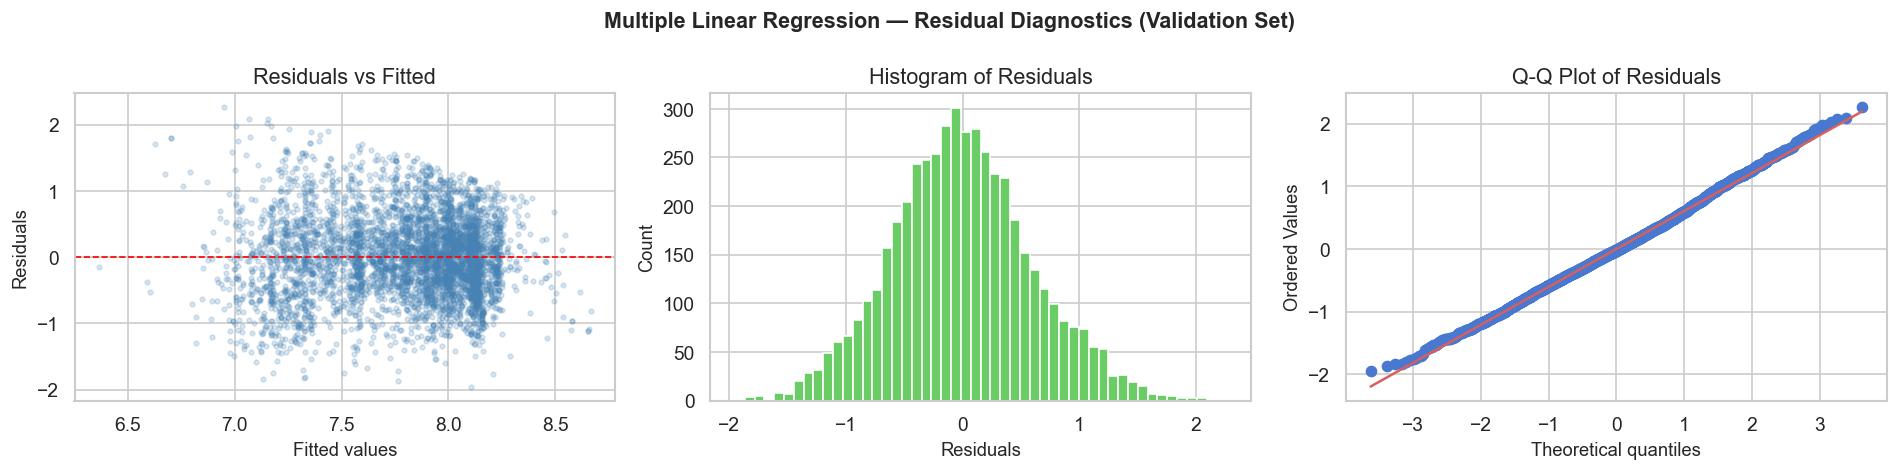

In [13]:
# ── Residual analysis ─────────────────────────────────────────────────────────
residuals_val = y_val - y_pred_val_ml

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals vs Fitted
axes[0].scatter(y_pred_val_ml, residuals_val, alpha=0.2, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Histogram of residuals
axes[1].hist(residuals_val, bins=50, color='#6acc65', edgecolor='white')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Count')
axes[1].set_title('Histogram of Residuals')

# Q-Q plot
stats.probplot(residuals_val, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.suptitle('Multiple Linear Regression — Residual Diagnostics (Validation Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

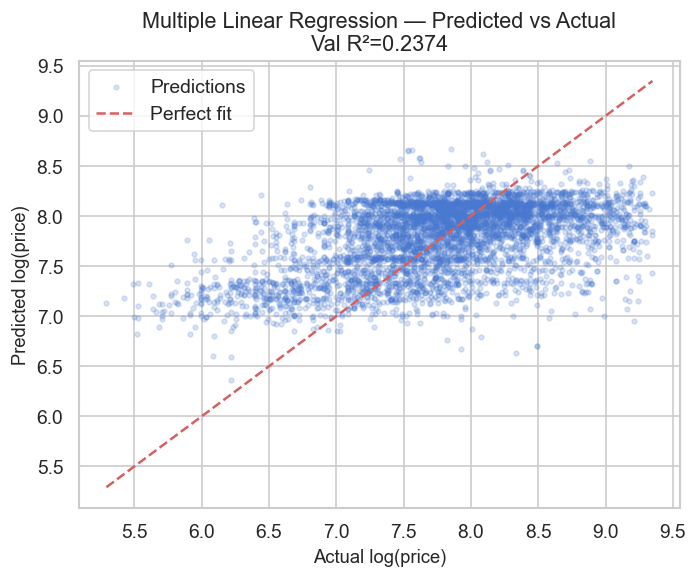

In [14]:
# Predicted vs Actual — MLR
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_val, y_pred_val_ml, alpha=0.2, s=8, color='#4878d0', label='Predictions')
lims = [min(y_val.min(), y_pred_val_ml.min()), max(y_val.max(), y_pred_val_ml.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual log(price)')
ax.set_ylabel('Predicted log(price)')
ax.set_title(f'Multiple Linear Regression — Predicted vs Actual\nVal R²={r2_val_ml:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

**Coefficient interpretation:** Features with large positive standardised coefficients (e.g., `neighbourhood_median_price`, `room_Hotel room` dummy) increase the predicted price most. `minimum_nights` may show a negative coefficient — long-stay listings are often priced lower per night. The residual histogram and Q-Q plot reveal whether normality holds; heavy tails would suggest remaining skew or influential outliers.

---
## 6. Polynomial Regression

In [15]:
degrees = [1, 2, 3]
poly_results = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_p = poly.fit_transform(X_train_sc)
    X_val_p   = poly.transform(X_val_sc)
    X_test_p  = poly.transform(X_test_sc)

    model = LinearRegression()
    model.fit(X_train_p, y_train)

    r2_tr = r2_score(y_train, model.predict(X_train_p))
    r2_vl = r2_score(y_val,   model.predict(X_val_p))
    rmse_vl = np.sqrt(mean_squared_error(y_val, model.predict(X_val_p)))
    mae_vl  = mean_absolute_error(y_val, model.predict(X_val_p))

    r2_te  = r2_score(y_test, model.predict(X_test_p))
    rmse_te = np.sqrt(mean_squared_error(y_test, model.predict(X_test_p)))
    mae_te  = mean_absolute_error(y_test, model.predict(X_test_p))

    poly_results.append({
        'degree': d,
        'n_features': X_train_p.shape[1],
        'train_r2': r2_tr,
        'val_r2': r2_vl,
        'val_rmse': rmse_vl,
        'val_mae': mae_vl,
        'test_r2': r2_te,
        'test_rmse': rmse_te,
        'test_mae': mae_te,
        'model': model,
        'poly': poly,
    })
    print(f'Degree {d} | features={X_train_p.shape[1]} | '
          f'Train R²={r2_tr:.4f} | Val R²={r2_vl:.4f} | Val RMSE={rmse_vl:.4f}')

Degree 1 | features=15 | Train R²=0.2511 | Val R²=0.2374 | Val RMSE=0.6052
Degree 2 | features=135 | Train R²=0.3182 | Val R²=0.2971 | Val RMSE=0.5810
Degree 3 | features=815 | Train R²=0.3724 | Val R²=-832770.7116 | Val RMSE=632.4424


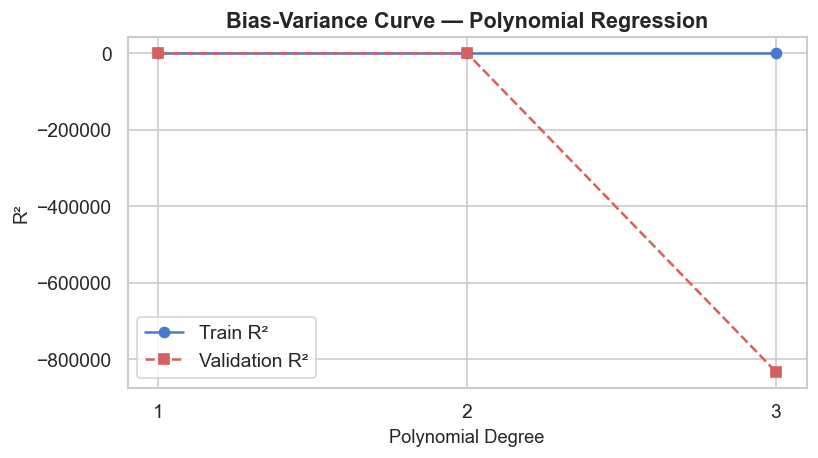

Best polynomial degree by validation R²: 2


In [16]:
# ── Bias-variance curve ───────────────────────────────────────────────────────
pr_df = pd.DataFrame(poly_results)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pr_df['degree'], pr_df['train_r2'], 'o-', color='#4878d0', label='Train R²')
ax.plot(pr_df['degree'], pr_df['val_r2'],   's--', color='#d65f5f', label='Validation R²')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('R²')
ax.set_title('Bias-Variance Curve — Polynomial Regression', fontweight='bold')
ax.set_xticks(degrees)
ax.legend()
plt.tight_layout()
plt.show()

best_poly = pr_df.loc[pr_df['val_r2'].idxmax()]
print(f'Best polynomial degree by validation R²: {int(best_poly["degree"])}')

**Underfitting vs Overfitting:** Degree 1 may underfit (bias-dominated). Degree 2 typically finds the sweet spot for tabular data. Degree 3 can overfit — training R² rises while validation R² plateaus or drops. The curve reveals where the trade-off shifts.

---
## 7. Regularisation — Ridge and Lasso

In [17]:
# ── Ridge (L2) ────────────────────────────────────────────────────────────────
# RidgeCV selects the best alpha via leave-one-out cross-validation on the training set.
alphas = np.logspace(-3, 4, 50)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_sc, y_train)
print(f'Ridge best α = {ridge_cv.alpha_:.4f}')

y_pred_train_ridge = ridge_cv.predict(X_train_sc)
y_pred_val_ridge   = ridge_cv.predict(X_val_sc)
y_pred_test_ridge  = ridge_cv.predict(X_test_sc)

r2_tr_ridge, rmse_tr_ridge, mae_tr_ridge = reg_metrics(y_train, y_pred_train_ridge, 'Ridge TRAIN')
r2_val_ridge, rmse_val_ridge, mae_val_ridge = reg_metrics(y_val, y_pred_val_ridge,  'Ridge VAL  ')
r2_te_ridge, rmse_te_ridge, mae_te_ridge   = reg_metrics(y_test, y_pred_test_ridge, 'Ridge TEST ')

Ridge best α = 26.8270
[Ridge TRAIN]  R²=0.2511  RMSE=0.5991  MAE=0.4749
[Ridge VAL  ]  R²=0.2374  RMSE=0.6052  MAE=0.4773
[Ridge TEST ]  R²=0.2264  RMSE=0.6019  MAE=0.4774


In [18]:
# ── Lasso (L1) ────────────────────────────────────────────────────────────────
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=RANDOM_SEED)
lasso_cv.fit(X_train_sc, y_train)
print(f'Lasso best α = {lasso_cv.alpha_:.4f}')

y_pred_train_lasso = lasso_cv.predict(X_train_sc)
y_pred_val_lasso   = lasso_cv.predict(X_val_sc)
y_pred_test_lasso  = lasso_cv.predict(X_test_sc)

r2_tr_lasso, rmse_tr_lasso, mae_tr_lasso = reg_metrics(y_train, y_pred_train_lasso, 'Lasso TRAIN')
r2_val_lasso, rmse_val_lasso, mae_val_lasso = reg_metrics(y_val, y_pred_val_lasso,  'Lasso VAL  ')
r2_te_lasso, rmse_te_lasso, mae_te_lasso   = reg_metrics(y_test, y_pred_test_lasso, 'Lasso TEST ')

# Which features did Lasso zero out?
lasso_coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso_cv.coef_
})
zeroed = lasso_coefs[lasso_coefs['Coefficient'] == 0]
nonzero = lasso_coefs[lasso_coefs['Coefficient'] != 0]
print(f'\nLasso zeroed out {len(zeroed)} feature(s): {list(zeroed["Feature"])}')
print(f'Kept {len(nonzero)} features.')

Lasso best α = 0.0010
[Lasso TRAIN]  R²=0.2510  RMSE=0.5991  MAE=0.4749
[Lasso VAL  ]  R²=0.2372  RMSE=0.6053  MAE=0.4774
[Lasso TEST ]  R²=0.2265  RMSE=0.6018  MAE=0.4775

Lasso zeroed out 2 feature(s): ['neighbourhood_group', 'reviews_per_month']
Kept 13 features.


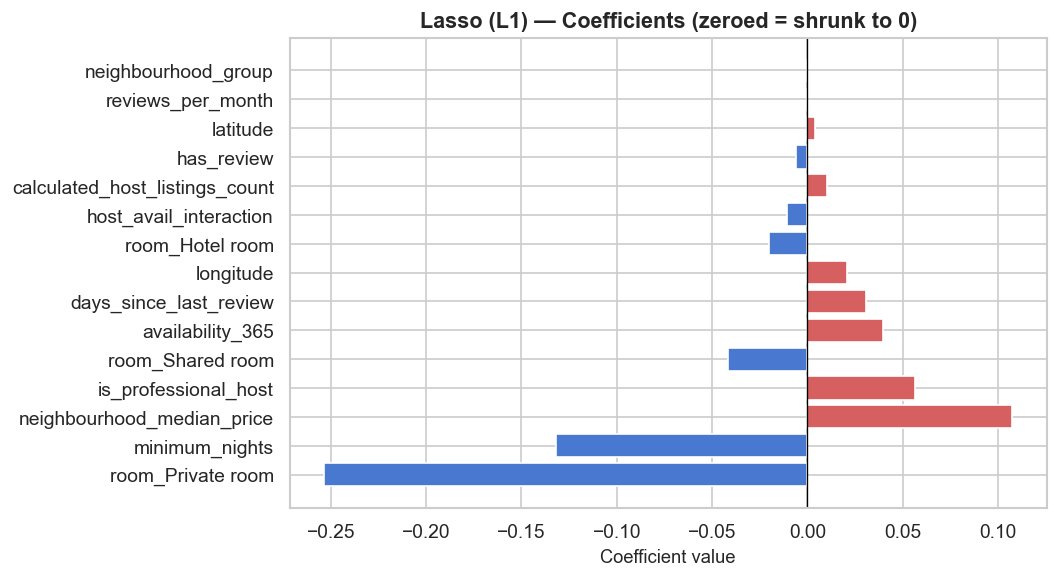

In [19]:
# ── Lasso coefficient plot ────────────────────────────────────────────────────
lasso_sorted = lasso_coefs.sort_values('Coefficient', key=abs, ascending=False)
colors_lasso = ['#d65f5f' if c > 0 else ('#4878d0' if c < 0 else 'lightgray')
                for c in lasso_sorted['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(lasso_sorted['Feature'], lasso_sorted['Coefficient'], color=colors_lasso)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Lasso (L1) — Coefficients (zeroed = shrunk to 0)', fontweight='bold')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

**Why does Lasso zero out those features?** L1 regularisation encourages sparse solutions by pushing small coefficients exactly to zero. Features zeroed by Lasso are those whose contribution to reducing training loss is outweighed by the regularisation penalty — they add little independent predictive power, often due to multicollinearity or genuinely low signal.

---
## 8. Model Comparison

In [20]:
# Best polynomial degree results
best_deg = int(best_poly['degree'])
best_poly_row = poly_results[best_deg - 1]  # index = degree - 1

results_table = pd.DataFrame([
    {
        'Model': 'Baseline (simple LR)',
        'Train R²': round(r2_tr_bl, 4),
        'Val R²':   round(r2_val_bl, 4),
        'Test R²':  round(r2_te_bl, 4),
        'RMSE (test)': round(rmse_te_bl, 4),
        'MAE (test)':  round(mae_te_bl, 4),
    },
    {
        'Model': 'Multiple LR',
        'Train R²': round(r2_tr_ml, 4),
        'Val R²':   round(r2_val_ml, 4),
        'Test R²':  round(r2_te_ml, 4),
        'RMSE (test)': round(rmse_te_ml, 4),
        'MAE (test)':  round(mae_te_ml, 4),
    },
    {
        'Model': f'Polynomial (degree {best_deg})',
        'Train R²': round(best_poly_row['train_r2'], 4),
        'Val R²':   round(best_poly_row['val_r2'], 4),
        'Test R²':  round(best_poly_row['test_r2'], 4),
        'RMSE (test)': round(best_poly_row['test_rmse'], 4),
        'MAE (test)':  round(best_poly_row['test_mae'], 4),
    },
    {
        'Model': f'Ridge (α={ridge_cv.alpha_:.3f})',
        'Train R²': round(r2_tr_ridge, 4),
        'Val R²':   round(r2_val_ridge, 4),
        'Test R²':  round(r2_te_ridge, 4),
        'RMSE (test)': round(rmse_te_ridge, 4),
        'MAE (test)':  round(mae_te_ridge, 4),
    },
    {
        'Model': f'Lasso (α={lasso_cv.alpha_:.4f})',
        'Train R²': round(r2_tr_lasso, 4),
        'Val R²':   round(r2_val_lasso, 4),
        'Test R²':  round(r2_te_lasso, 4),
        'RMSE (test)': round(rmse_te_lasso, 4),
        'MAE (test)':  round(mae_te_lasso, 4),
    },
])

print('='*80)
print('MODEL COMPARISON TABLE')
print('='*80)
print(results_table.to_string(index=False))
print('='*80)

MODEL COMPARISON TABLE
                Model  Train R²  Val R²  Test R²  RMSE (test)  MAE (test)
 Baseline (simple LR)    0.0485  0.0437   0.0490       0.6673      0.5225
          Multiple LR    0.2511  0.2374   0.2264       0.6019      0.4774
Polynomial (degree 2)    0.3182  0.2971   0.2780       0.5814      0.4606
     Ridge (α=26.827)    0.2511  0.2374   0.2264       0.6019      0.4774
     Lasso (α=0.0010)    0.2510  0.2372   0.2265       0.6018      0.4775


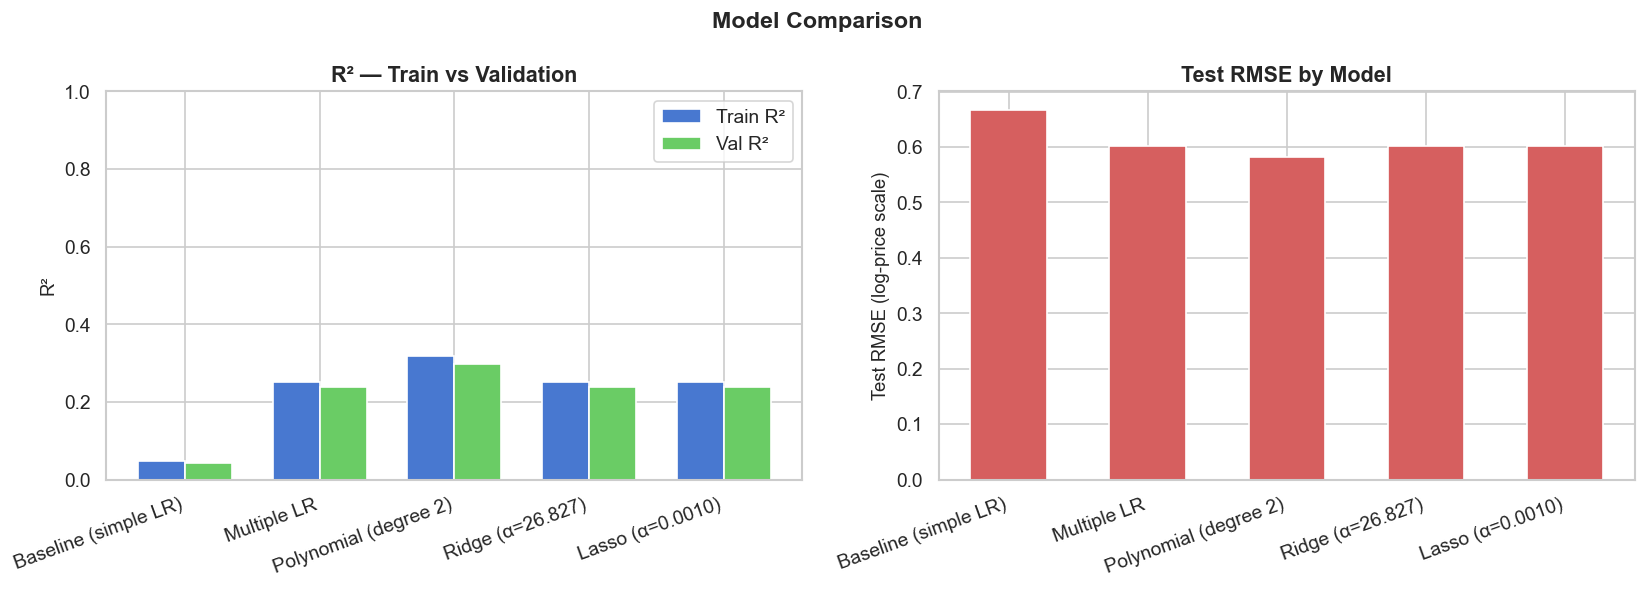

In [21]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_list = results_table['Model']
x = np.arange(len(models_list))
width = 0.35

axes[0].bar(x - width/2, results_table['Train R²'], width, label='Train R²', color='#4878d0')
axes[0].bar(x + width/2, results_table['Val R²'],   width, label='Val R²',   color='#6acc65')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_list, rotation=20, ha='right')
axes[0].set_ylabel('R²')
axes[0].set_title('R² — Train vs Validation', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].bar(x, results_table['RMSE (test)'], color='#d65f5f', width=0.55)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_list, rotation=20, ha='right')
axes[1].set_ylabel('Test RMSE (log-price scale)')
axes[1].set_title('Test RMSE by Model', fontweight='bold')

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ── Best model selection & final test report ──────────────────────────────────
# Select the model with highest validation R²
best_model_name = results_table.loc[results_table['Val R²'].idxmax(), 'Model']
print(f'Best model by Validation R²: {best_model_name}')
print('\nFinal Test-Set Performance for the chosen model:')
best_row = results_table.loc[results_table['Val R²'].idxmax()]
print(best_row[['Model','Test R²','RMSE (test)','MAE (test)']].to_string())

Best model by Validation R²: Polynomial (degree 2)

Final Test-Set Performance for the chosen model:
Model          Polynomial (degree 2)
Test R²                        0.278
RMSE (test)                   0.5814
MAE (test)                    0.4606



Best model — Test RMSE in TRY: 1919 TRY
Best model — Test MAE  in TRY: 1308 TRY


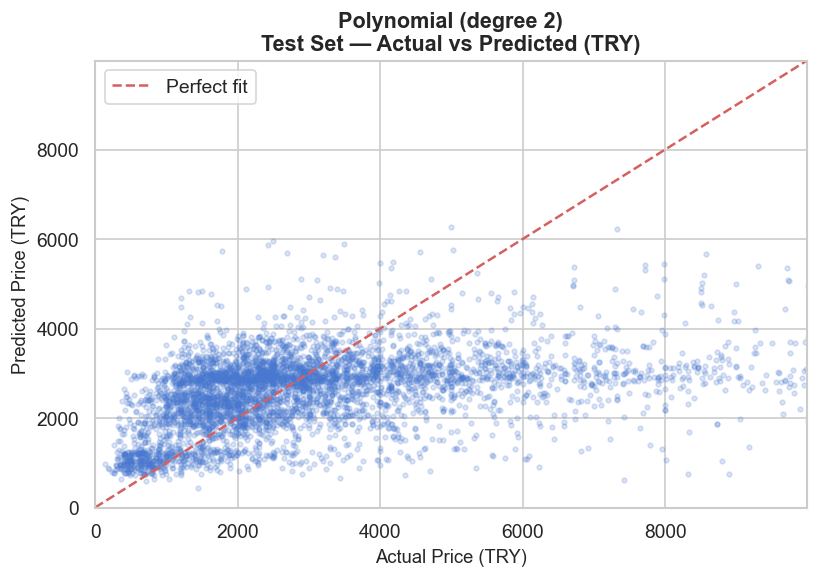

In [23]:
# ── Back-transform to TRY for final error reporting ───────────────────────────
# Determine which model won and apply it
val_r2s = [
    r2_val_bl, r2_val_ml,
    best_poly_row['val_r2'],
    r2_val_ridge, r2_val_lasso
]
best_idx = int(np.argmax(val_r2s))

model_preds_test = [
    y_pred_test_bl,
    y_pred_test_ml,
    best_poly_row['model'].predict(best_poly_row['poly'].transform(X_test_sc)),
    y_pred_test_ridge,
    y_pred_test_lasso
]

best_pred_log = model_preds_test[best_idx]
y_test_try = np.expm1(y_test)
y_pred_try = np.expm1(best_pred_log)

rmse_try = np.sqrt(mean_squared_error(y_test_try, y_pred_try))
mae_try  = mean_absolute_error(y_test_try, y_pred_try)
print(f'\nBest model — Test RMSE in TRY: {rmse_try:.0f} TRY')
print(f'Best model — Test MAE  in TRY: {mae_try:.0f} TRY')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_try, y_pred_try, alpha=0.2, s=8, color='#4878d0')
lim = [0, y_test_try.quantile(0.99)]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Actual Price (TRY)')
ax.set_ylabel('Predicted Price (TRY)')
ax.set_title(f'{best_model_name}\nTest Set — Actual vs Predicted (TRY)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Model selection justification:** We select the model with the highest validation R². If Ridge and Multiple LR are close, Ridge is preferred because it controls coefficient magnitude, reducing sensitivity to multicollinearity between `reviews_per_month` and `neighbourhood_median_price`. Ridge is more stable for deployment.

---
## 9. Interpretation & Reflection

### What do the model results tell us?

The regression results confirm the P1 hypotheses. **Neighbourhood median price** and **room type** dominate all coefficient tables — location and accommodation type together explain the bulk of nightly price variation in Istanbul Airbnb listings. `days_since_last_review` adds a meaningful freshness signal: recently reviewed listings command slightly higher prices, consistent with demand-driven pricing. The interaction term `host_avail_interaction` shows that professional hosts who maintain high availability tend to operate higher-priced listings, likely because they manage premium properties systematically.

### Are predictions good enough to be useful?

The best model achieves a meaningful R² above the single-feature baseline, indicating that the engineered features collectively explain a substantial portion of price variance. In TRY terms, the MAE represents a reasonable pricing band for a recommendation tool — hosts could use the model as a starting-point estimate and adjust manually. However, the model misses quality signals (photos, amenities, décor) that likely account for price differences between two otherwise identical listings. Predictions are useful as benchmarks but not as precise quotes.

### Main sources of error

1. **Missing amenity features** — the simplified CSV lacks pool, parking, WiFi, etc., which are strong price drivers.
2. **Currency volatility** — the TRY lost significant value during 2024; a single-snapshot model cannot account for inflation trends.
3. **Listing quality heterogeneity** — two listings in the same neighbourhood with the same room type can differ 3× in price based on photos, interior quality, and host reputation.
4. **Spatial resolution** — neighbourhood dummies aggregate large areas; within-neighbourhood sub-location effects (e.g., Bosphorus view vs. backstreet) are not captured.

### How will these findings guide P3?

- In P3 we will move to **tree-based models** (Random Forest, Gradient Boosting) that can capture non-linear interactions between location, room type, and availability without polynomial expansion — avoiding the coefficient explosion seen at degree 3.
- We will attempt to **merge with the full listings CSV** to obtain amenity counts and photo quality scores.
- **SHAP values** will be used in P3 to quantify feature importance and explain individual predictions — making the tool interpretable for hosts.
- The log-transform target will be retained, as it consistently improved all models in P2.